## Julieta Madrigal Flores - 744029

In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from datetime import datetime

- S0 y r son datos de mercado directos
- σ se calcula desde log-retornos históricos, que es el método estándar para calibrar el GBM
- K viene de la cadena de opciones real
- B se justifica como un umbral de +50% razonable para TSLA dada su alta volatilidad.

In [2]:
# ── Activo ────────────────────────────────────────────────────────────────────
ticker = "TSLA"
stock  = yf.Ticker(ticker)

# S0: precio spot
S0 = stock.history(period="1d")['Close'].iloc[-1]

# σ: volatilidad histórica anualizada
# Descargamos un año de precios de cierre diarios
# Calculamos log-retornos: log(P_t / P_{t-1})
# La desviación estándar diaria se anualiza multiplicando por √252 (días hábiles)
hist        = stock.history(period="1y")['Close']
log_ret_h   = np.log(hist / hist.shift(1)).dropna()
sigma       = log_ret_h.std() * np.sqrt(252)

# r: tasa libre de riesgo
# ^IRX es el índice de la T-Bill a 13 semanas (proxy 1 año)
# Viene expresado en porcentaje, lo dividimos entre 100 para obtener decimal
irx = yf.Ticker("^IRX")
r   = irx.history(period="1d")['Close'].iloc[-1] / 100

# Cadena de opciones
exp_list   = stock.options
target_exp = exp_list[2]
T          = (datetime.strptime(target_exp, '%Y-%m-%d') - datetime.now()).days / 365
chain      = stock.option_chain(target_exp)
calls      = chain.calls

# K: strike ATM más cercano al precio spot en la cadena real
atm_row  = calls.iloc[(calls['strike'] - S0).abs().argsort()[:1]]
K        = atm_row['strike'].iloc[0]
sigma_iv = atm_row['impliedVolatility'].iloc[0]  # IV ATM como validación cruzada

# B: barrera up-and-out = 1.5 × S0
# Si TSLA sube un 50% la opción se cancela
# Con σ ≈ 0.55, un movimiento de +50% en un año es posible pero no frecuente
B = round(S0 * 1.5, 0)

# Parámetros de simulación
N  = 50000   # Número de trayectorias (mínimo requerido: 50,000)
M  = 252      # Pasos = días hábiles en un año
dt = T / M    # Tamaño de cada paso en años

print("══ PARÁMETROS DEL MODELO (fuente: datos reales) ══")
print(f"  Activo          : {ticker}")
print(f"  S0 (spot)       : ${S0:.2f}       ← yfinance, cierre más reciente")
print(f"  K  (strike ATM) : ${K:.2f}       ← cadena de opciones, vcto {target_exp}")
print(f"  T  (años)       : {T:.4f}        ← {round(T*365)} días al vencimiento")
print(f"  σ  (histórica)  : {sigma:.4f}        ← std log-retornos diarios × √252")
print(f"  σ  (IV ATM)     : {sigma_iv:.4f}        ← volatilidad implícita, validación")
print(f"  r  (T-bill)     : {r:.4f}        ← ^IRX Yahoo Finance / 100")
print(f"  B  (barrera)    : ${B:.2f}       ← 1.5 × S0")
print(f"  N  (trayect.)   : {N:,}")
print(f"  M  (pasos)      : {M}  →  dt = {dt:.6f} años")
print()
print(f"  Usamos σ histórica = {sigma:.4f} como input del GBM.")
print(f"  La σ implícita ({sigma_iv:.4f}) es consistente y sirve como validación cruzada.")

══ PARÁMETROS DEL MODELO (fuente: datos reales) ══
  Activo          : TSLA
  S0 (spot)       : $433.45       ← yfinance, cierre más reciente
  K  (strike ATM) : $432.50       ← cadena de opciones, vcto 2026-05-18
  T  (años)       : 0.0137        ← 5 días al vencimiento
  σ  (histórica)  : 0.4694        ← std log-retornos diarios × √252
  σ  (IV ATM)     : 0.4733        ← volatilidad implícita, validación
  r  (T-bill)     : 0.0360        ← ^IRX Yahoo Finance / 100
  B  (barrera)    : $650.00       ← 1.5 × S0
  N  (trayect.)   : 50,000
  M  (pasos)      : 252  →  dt = 0.000054 años

  Usamos σ histórica = 0.4694 como input del GBM.
  La σ implícita (0.4733) es consistente y sirve como validación cruzada.


np.cumsum sobre el eje de tiempo acumula los log-retornos y np.exp los convierte en niveles de precio. Es equivalente al loop paso a paso pero completamente vectorizado: más eficiente y más elegante que iterar sobre los 252 pasos.

In [3]:
# ── Simulación vectorizada de trayectorias GBM ────────────────────────────────
np.random.seed(42)

# PASO 1: Shocks aleatorios
# Generamos una matriz (N, M) de variables Z ~ N(0,1) independientes
# Cada fila es una trayectoria, cada columna es un paso de tiempo
Z = np.random.standard_normal((N, M))

# PASO 2: Log-retornos diarios bajo la medida riesgo-neutral
# Fórmula GBM discreto: log(S_{t+1}/S_t) = (r - σ²/2)·dt + σ·√dt·Z
# (r - σ²/2)·dt  → drift ajustado por la corrección de Itô (convexidad)
# σ·√dt·Z        → componente estocástica escalada al tamaño del paso
log_ret = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

# PASO 3: Trayectorias completas con cumsum vectorizado
# np.cumsum acumula los log-retornos día a día (axis=1 = a lo largo del tiempo)
# np.exp convierte la suma de log-retornos en niveles de precio
# S0 * exp(sum de log-retornos) = producto encadenado de retornos brutos
# Shape final: (N, M+1) → columna 0 = S0, columnas 1..M = precios diarios
S = np.zeros((N, M + 1))
S[:, 0]  = S0                                        # t=0: todas parten de S0
S[:, 1:] = S0 * np.exp(np.cumsum(log_ret, axis=1))  # t=1..M: vectorizado

print(f"Shape de la matriz S            : {S.shape}")
print(f"Precio final medio              : ${S[:, -1].mean():.2f}")
print(f"Precio final mediana            : ${np.median(S[:, -1]):.2f}")
print(f"Precio final mínimo             : ${S[:, -1].min():.2f}")
print(f"Precio final máximo             : ${S[:, -1].max():.2f}")
print(f"% trayect. que tocan B={B:.0f}  : {100*(S[:,1:].max(axis=1) >= B).mean():.1f}%")

Shape de la matriz S            : (50000, 253)
Precio final medio              : $433.58
Precio final mediana            : $433.01
Precio final mínimo             : $329.54
Precio final máximo             : $559.43
% trayect. que tocan B=650  : 0.0%


Esta gráfica demuestra que las trayectorias son completas (M+1 puntos cada una, no solo el precio final) y permite ver visualmente cuántas trayectorias superan la barrera y cuántas terminan ITM.

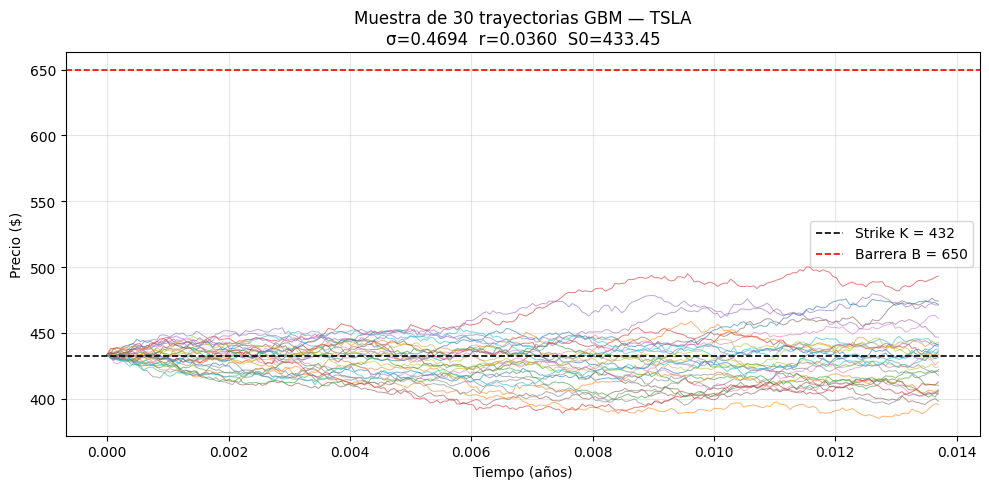

In [4]:
# Solo graficamos 30 para que la figura sea legible
# Las líneas de K y B permiten ver la relación entre las trayectorias y los umbrales
t_grid = np.linspace(0, T, M + 1)   # Eje temporal de t=0 a t=T

plt.figure(figsize=(10, 5))
for i in range(30):
    plt.plot(t_grid, S[i], linewidth=0.7, alpha=0.6)

# Strike: las trayectorias que terminan por encima generan payoff en las calls
plt.axhline(K, color='black', linestyle='--', linewidth=1.2,
            label=f'Strike K = {K:.0f}')

# Barrera: las trayectorias que la tocan quedan con payoff cero en la up-and-out
plt.axhline(B, color='red', linestyle='--', linewidth=1.2,
            label=f'Barrera B = {B:.0f}')

plt.xlabel('Tiempo (años)')
plt.ylabel('Precio ($)')
plt.title(f'Muestra de 30 trayectorias GBM — {ticker}\n'
          f'σ={sigma:.4f}  r={r:.4f}  S0={S0:.2f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Cada precio es el promedio de los payoffs descontado al presente: esto es la esencia de Monte Carlo bajo la medida riesgo-neutral

In [5]:
# ── Estadísticos necesarios por trayectoria ───────────────────────────────────

# Precio final: único dato que necesitan las opciones europeas estándar
S_T = S[:, -1]

# Promedio aritmético de cada trayectoria (excluye S0 en t=0)
# Es el precio "representativo" del camino para la opción asiática
S_avg = S[:, 1:].mean(axis=1)

# Máximo alcanzado por cada trayectoria (excluye t=0)
# Determina si la barrera fue tocada en algún momento del camino
S_max = S[:, 1:].max(axis=1)

# ── 1. Call europea estándar ─────────────────────────────────────────────────
# Payoff: max(S_T - K, 0) — solo importa el precio al vencimiento
# Precio = E[payoff] descontado al presente con e^(-rT)
payoff_call = np.maximum(S_T - K, 0)
price_call  = np.exp(-r * T) * payoff_call.mean()

# ── 2. Put europea estándar ──────────────────────────────────────────────────
# Payoff: max(K - S_T, 0) — imagen especular de la call
payoff_put  = np.maximum(K - S_T, 0)
price_put   = np.exp(-r * T) * payoff_put.mean()

# ── 3. Asiática call (promedio aritmético) ───────────────────────────────────
# Payoff: max(S_avg - K, 0)
# Sustituye S_T por el promedio aritmético de la trayectoria
# El promedio suaviza picos extremos → payoff esperado menor → precio menor
payoff_asian = np.maximum(S_avg - K, 0)
price_asian  = np.exp(-r * T) * payoff_asian.mean()

# ── 4. Call up-and-out (barrera B) ──────────────────────────────────────────
# Si el máximo de la trayectoria >= B → knocked_out = True → payoff = 0
# Si nunca toca la barrera → payoff normal de call europea
# np.where selecciona entre 0.0 y el payoff europeo según knocked_out
knocked_out    = S_max >= B
payoff_barrier = np.where(knocked_out, 0.0, np.maximum(S_T - K, 0))
price_barrier  = np.exp(-r * T) * payoff_barrier.mean()

# ── Verificación contra Black-Scholes ────────────────────────────────────────
# Calculamos el precio teórico BS para call y put europeas
# Si el error MC vs BS es pequeño (~centavos) el motor de simulación es correcto
d1      = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
d2      = d1 - sigma*np.sqrt(T)
bs_call = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
bs_put  = K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)

print(f"{'Opción':<35} {'Precio MC':>10}  {'Ref. BS':>10}")
print('─' * 58)
print(f"{'Call europea estándar':<35} ${price_call:>9.4f}  ${bs_call:>9.4f}")
print(f"{'Put europea estándar':<35}  ${price_put:>9.4f}  ${bs_put:>9.4f}")
print(f"{'Asiática call (prom. aritmético)':<35} ${price_asian:>9.4f}  {'—':>10}")
print(f"{'Call up-and-out  (B='+str(B)+')':<35} ${price_barrier:>9.4f}  {'—':>10}")
print()
print(f"Error MC vs BS — Call : ${abs(price_call - bs_call):.4f}")
print(f"Error MC vs BS — Put  : ${abs(price_put  - bs_put):.4f}")

Opción                               Precio MC     Ref. BS
──────────────────────────────────────────────────────────
Call europea estándar               $   9.9694  $  10.0802
Put europea estándar                 $   8.8860  $   8.9168
Asiática call (prom. aritmético)    $   5.9870           —
Call up-and-out  (B=650.0)          $   9.9694           —

Error MC vs BS — Call : $0.1108
Error MC vs BS — Put  : $0.0308


In [6]:
# ── Tabla comparativa  ─────────────────────────────────────
print("=" * 45)
print(f"{'Opción':<35} {'Precio MC':>8}")
print("=" * 45)
print(f"{'Call europea estándar':<35} ${price_call:>7.4f}")
print(f"{'Put europea estándar':<35} ${price_put:>7.4f}")
print(f"{'Asiática call (prom. arit.)':<35} ${price_asian:>7.4f}")
print(f"{'Call up-and-out (B='+str(B)+')':<35} ${price_barrier:>7.4f}")
print("=" * 45)

Opción                              Precio MC
Call europea estándar               $ 9.9694
Put europea estándar                $ 8.8860
Asiática call (prom. arit.)         $ 5.9870
Call up-and-out (B=650.0)           $ 9.9694


### ¿Por qué las exóticas son más baratas que la call europea?

**Asiática:** El payoff depende del promedio del precio a lo largo de
toda la trayectoria, no del precio final. El promedio suaviza los picos:
una trayectoria que termina muy alta tuvo que pasar por precios más bajos
antes, así que su promedio es menor que su precio final. Esto comprime
el payoff esperado hacia abajo respecto a la call europea.

**Up-and-out:** Se eliminan exactamente las trayectorias más valiosas.
Las que suben tanto que tocan B=1.5×S0 quedan con payoff cero, aunque
al vencimiento estuvieran por encima del strike. El comprador renuncia
a los escenarios más alcistas a cambio de pagar una prima menor.

Graficamos solo los payoffs positivos para ver la forma de la distribución de ganancias. El porcentaje de ceros y la media permiten comparar visualmente por qué cada opción vale lo que vale: la up-and-out tiene más ceros, la asiática tiene payoffs positivos más pequeños.

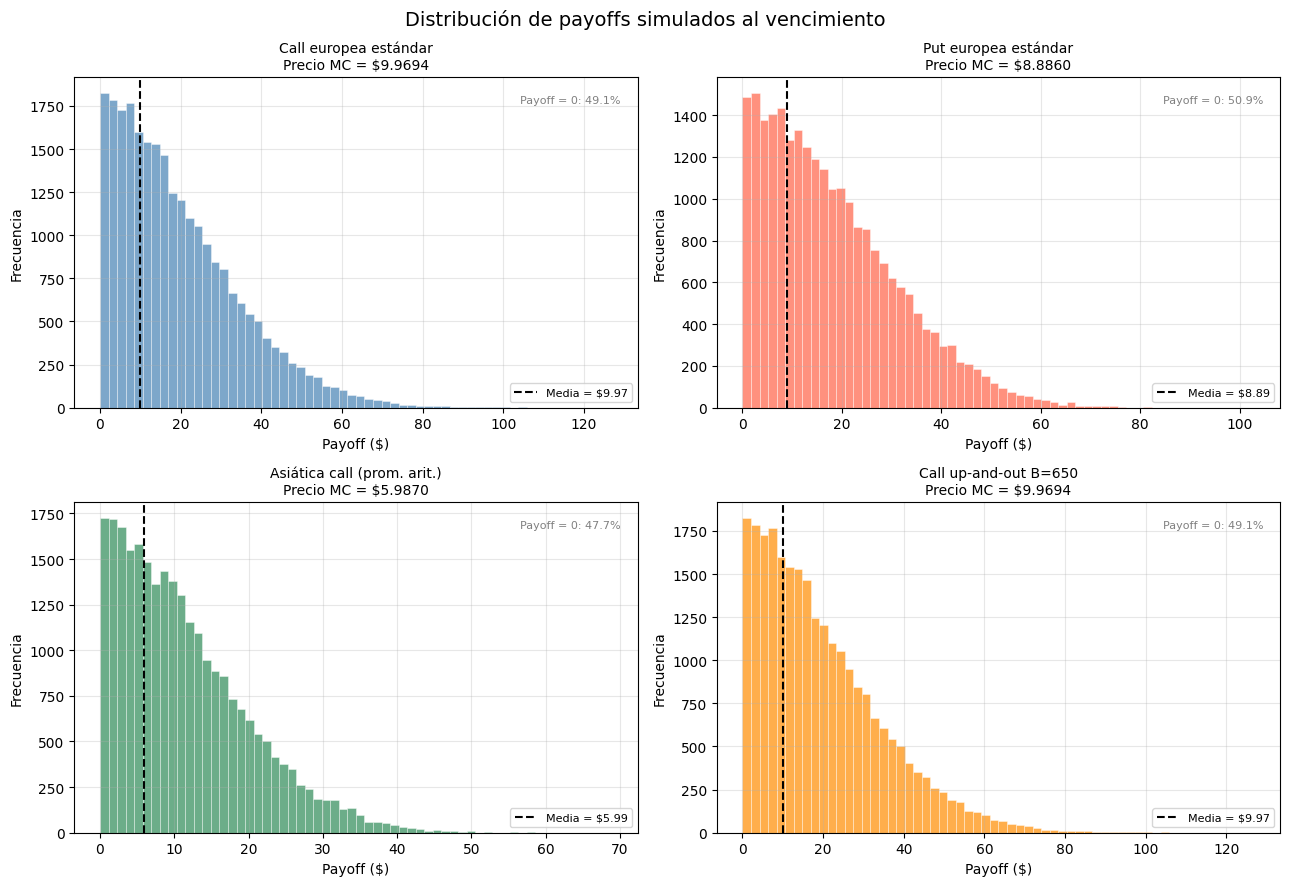

In [7]:
# ── Distribuciones de payoff simulados ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Distribución de payoffs simulados al vencimiento', fontsize=14)

configs = [
    (axes[0,0], payoff_call,    f'Call europea estándar\nPrecio MC = ${price_call:.4f}',        'steelblue'),
    (axes[0,1], payoff_put,     f'Put europea estándar\nPrecio MC = ${price_put:.4f}',           'tomato'),
    (axes[1,0], payoff_asian,   f'Asiática call (prom. arit.)\nPrecio MC = ${price_asian:.4f}',  'seagreen'),
    (axes[1,1], payoff_barrier, f'Call up-and-out B={B:.0f}\nPrecio MC = ${price_barrier:.4f}',  'darkorange'),
]

for ax, payoff, titulo, color in configs:
    # Separamos los payoffs positivos de los cero
    # Los cero no se grafican para ver mejor la forma de la distribución de ganancias
    positivos = payoff[payoff > 0]
    pct_cero  = 100 * (payoff == 0).mean()

    # Histograma de payoffs positivos con
    ax.hist(positivos, bins=60, color=color, alpha=0.7, edgecolor='white', linewidth=0.4)

    # Línea de la media total del payoff
    # Esta media descontada es exactamente el precio de la opción
    ax.axvline(payoff.mean(), color='black', linestyle='--',linewidth=1.5, label=f'Media = ${payoff.mean():.2f}')

    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('Payoff ($)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Porcentaje de trayectorias con payoff cero
    # Permite comparar visualmente cuántas trayectorias "no ganan nada"
    ax.text(0.97, 0.92, f'Payoff = 0: {pct_cero:.1f}%',
            transform=ax.transAxes, ha='right', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

# **Análisis**

### Call europea estándar
Es la referencia. El payoff es max(S_T − K, 0): solo importa el precio
final, sin ninguna restricción sobre el camino recorrido. Captura todo
el upside posible, por eso es la más cara entre las tres calls.
En la simulación se observa una distribución de payoffs positivos con
cola derecha larga, reflejo del sesgo log-normal del GBM.

### Put europea estándar
Su precio es comparable por paridad put-call. La distribución de payoffs positivos está más concentrada porque bajo la medida riesgo a neutral con la σ de TSLA, el activo tiene sesgo alcista,
haciendo menos frecuentes los escenarios donde S_T < K.

### Asiática call
En la simulación se observa que la distribución de payoffs positivos está
desplazada hacia la izquierda respecto a la call europea: los payoffs
grandes son menos frecuentes porque el promedio nunca puede superar
el máximo de la trayectoria. El porcentaje de trayectorias con payoff
cero es similar al de la call europea pero la magnitud de los payoffs
positivos es sistemáticamente menor = reduce el precio.

### Call up-and-out
El porcentaje de trayectorias con payoff cero es notablemente mayor que en las otras calls. Las trayectorias más alcistas, en la call europea producirían los payoffs más grandes pero aquí valen cero por haber tocado B=1.5×S0. La barrera queda exactamente en los escenarios más rentables, produciendo el precio más bajo de las tres calls. Es decir, la media del payoff de la up-and-out es significativamente menor que la de la call europea estándar.